In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from PIL import Image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
IMAGE_SIZE = 380
BATCH_SIZE = 8
EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_CLASSES = 31
DATASET_DIR = "/content/drive/MyDrive/FishDataset/FishImgDataset"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_DIR, "train"),
    transform=train_transforms
)
val_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_DIR, "val"),
    transform=val_test_transforms
)
test_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_DIR, "test"),
    transform=val_test_transforms
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print("Classes:", train_dataset.classes)
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: ['Bangus', 'Big Head Carp', 'Black Spotted Barb', 'Catfish', 'Climbing Perch', 'Fourfinger Threadfin', 'Freshwater Eel', 'Glass Perchlet', 'Goby', 'Gold Fish', 'Gourami', 'Grass Carp', 'Green Spotted Puffer', 'Indian Carp', 'Indo-Pacific Tarpon', 'Jaguar Gapote', 'Janitor Fish', 'Knifefish', 'Long-Snouted Pipefish', 'Mosquito Fish', 'Mudfish', 'Mullet', 'Pangasius', 'Perch', 'Scat Fish', 'Silver Barb', 'Silver Carp', 'Silver Perch', 'Snakehead', 'Tenpounder', 'Tilapia']
Train: 8793
Val: 2751
Test: 1760


In [ ]:
model = timm.create_model("efficientnet_b4", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)
print("EfficientNet-B4 loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

EfficientNet-B4 loaded


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

In [ ]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

def validate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return accuracy_score(all_labels, all_preds)

In [ ]:
best_val_acc = 0.0
for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    train_loss = train_one_epoch(model, train_loader)
    val_acc = validate(model, val_loader)
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_efficientnet_b4.pth")
        print("✔ Best model saved")


Epoch [1/10]


100%|██████████| 1100/1100 [1:20:05<00:00,  4.37s/it]


Train Loss: 1.0198
Val Accuracy: 0.9571
✔ Best model saved

Epoch [2/10]


100%|██████████| 1100/1100 [08:07<00:00,  2.26it/s]


Train Loss: 0.2147
Val Accuracy: 0.9782
✔ Best model saved

Epoch [3/10]


...

Train Loss: 0.0265
Val Accuracy: 0.9942
✔ Best model saved

Epoch [9/10]


100%|██████████| 1100/1100 [07:52<00:00,  2.33it/s]


Train Loss: 0.0234
Val Accuracy: 0.9927

Epoch [10/10]


100%|██████████| 1100/1100 [07:49<00:00,  2.34it/s]


Train Loss: 0.0143
Val Accuracy: 0.9942


In [ ]:
model.load_state_dict(torch.load("best_efficientnet_b4.pth"))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

Test Accuracy: 0.9903409090909091
                       precision    recall  f1-score   support

               Bangus       0.94      1.00      0.97        34
        Big Head Carp       0.98      1.00      0.99        43
   Black Spotted Barb       1.00      1.00      1.00        40
              Catfish       0.98      0.98      0.98        62
       Climbing Perch       1.00      0.93      0.97        30
 Fourfinger Threadfin       1.00      1.00      1.00        38
       Freshwater Eel       1.00      1.00      1.00        55
       Glass Perchlet       0.99      1.00      0.99        77
                 Goby       0.99      0.99      0.99       124
            Gold Fish       1.00      1.00      1.00        41
              Gourami       1.00      1.00      1.00        63
           Grass Carp       1.00      1.00      1.00       238
 Green Spotted Puffer       1.00      1.00      1.00        22
          Indian Carp       1.00      1.00      1.00        53
  Indo-Pacific Tarpo

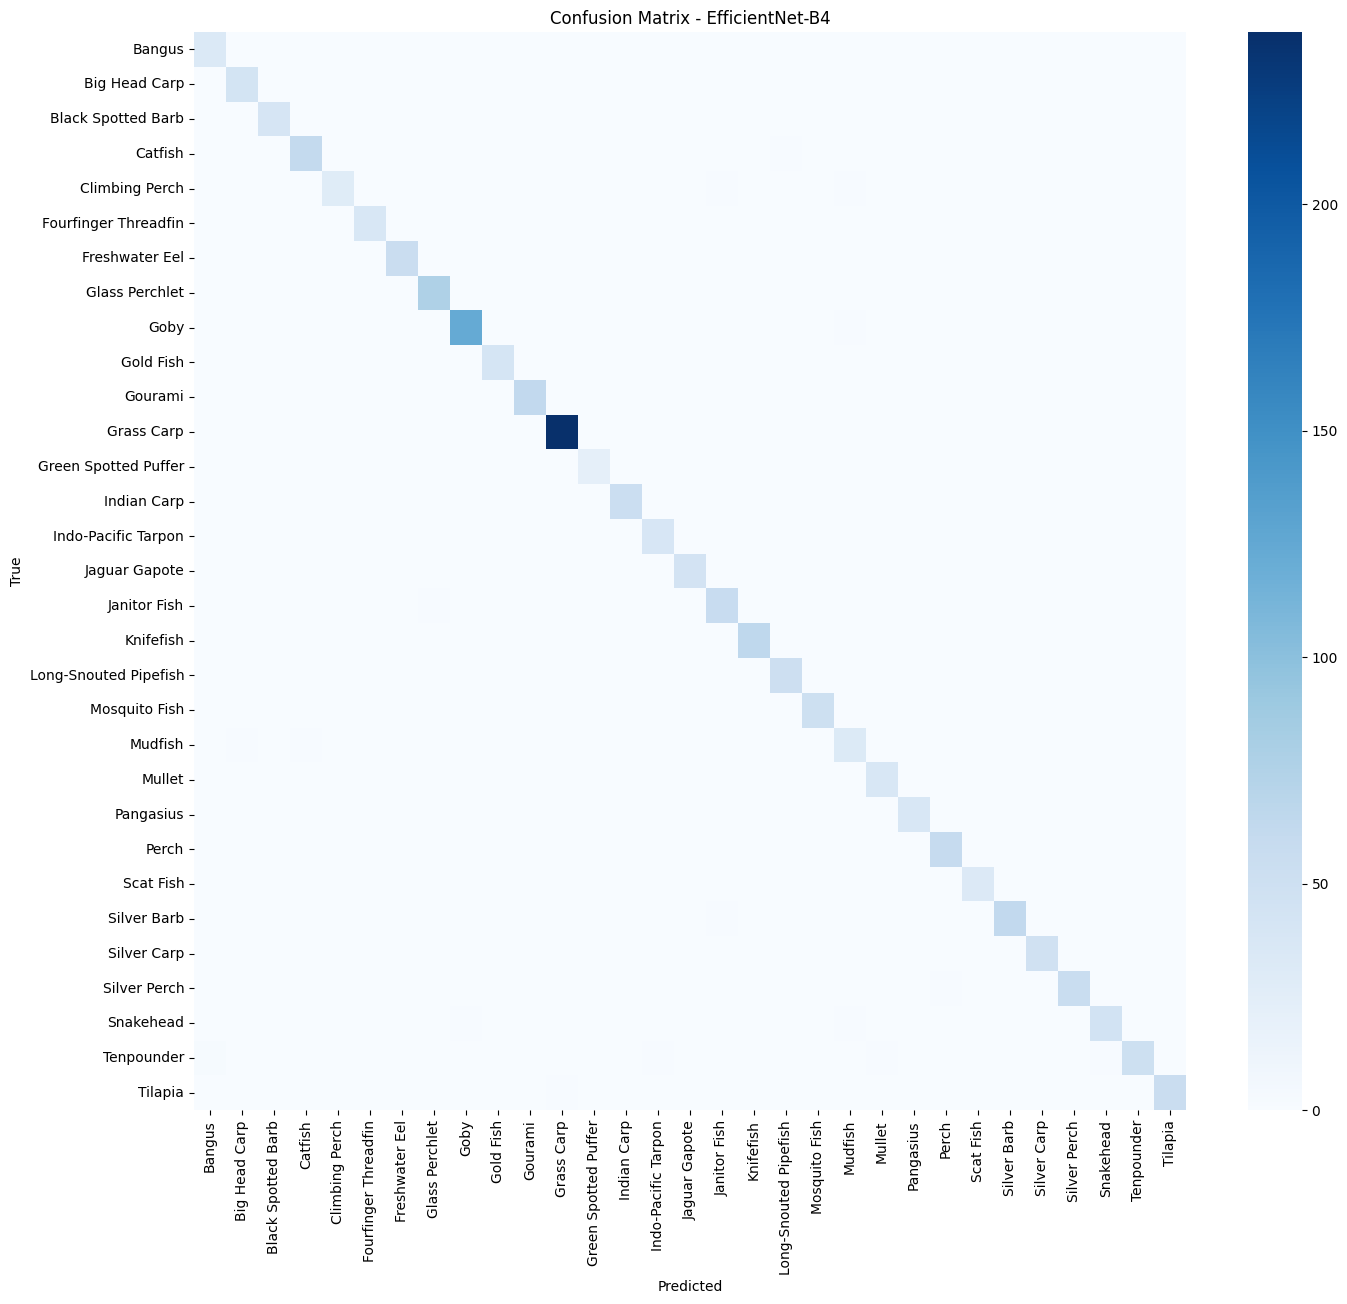

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16,14))
sns.heatmap(cm, cmap="Blues", xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - EfficientNet-B4")
plt.show()

In [ ]:
inference_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def predict_single_image(image_path):
    image = Image.open(image_path).convert("RGB")
    x = inference_transform(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)
        idx = torch.argmax(probs, dim=1).item()
    plt.imshow(image)
    plt.title(f"Prediction: {test_dataset.classes[idx]}\nConfidence: {probs[0, idx]:.2f}")
    plt.axis("off")
    plt.show()
predict_single_image("my_image.jpg")